# Apply Flight Condition Normalization 

Following the ideas from: [Remaining Useful Life Prediction of Aircraft Engines with Variable Length Input Sequences](https://papers.phmsociety.org/index.php/phmconf/article/view/3108) PHM2021 data challenge competition winner


**Note:** This script applies a **pretrained flight condition normalization pipeline**
to both **development (training)** and **test** datasets.  
No model training is performed her. The pipeline is loaded and applied unchanged.

In [10]:

import os

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from src.training.opcond_pipelines import EstimationPipeline
from src.helpers.filters import AdaptiveEMA

from experiment_config import (
    FAILED_THRESHOLD,
    FILT_NOISE_MEM,FILT_SMOOTH_STRENGTH, FILTER_DATA,OPCOND_DIR,ESTIMATION_DIR,DATA_DIR,MIN_CORR,MIN_RANGE
)
DATA_DIR

PosixPath('experiments/DS06')

## Configuration

In [11]:
data_split ='dev' #'test' # 

## 1. Load dataset

In [12]:
df = pd.read_csv(DATA_DIR/f'data_{data_split}.csv',dtype={"Fc": str})

## Load the pipeline

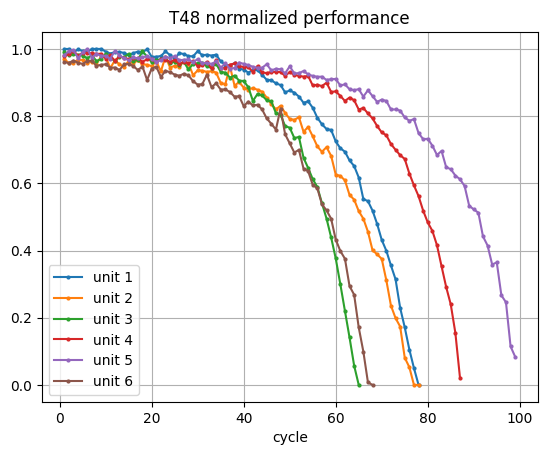

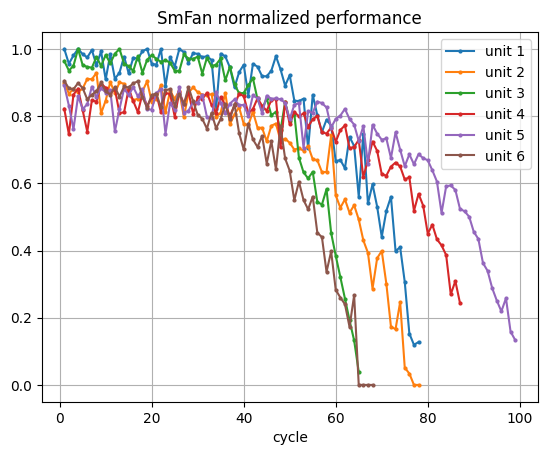

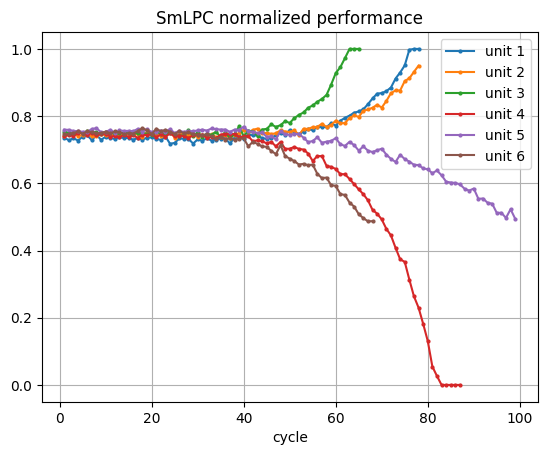

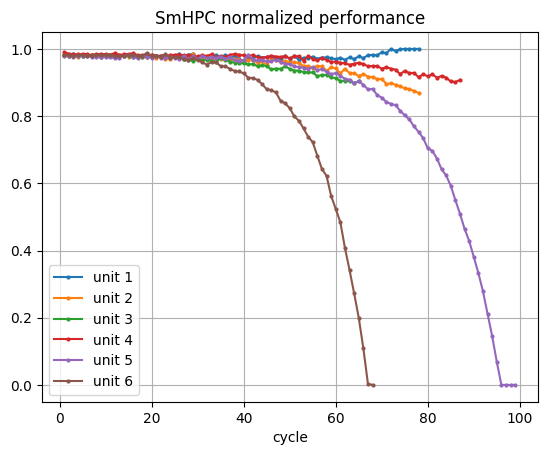

In [13]:
pipe:EstimationPipeline = joblib.load(OPCOND_DIR/"pipeline_best.joblib")

df_hi = pipe.transform(df)
for perf in pipe.get_performances():
    fig, ax = plt.subplots()
    ax.set_title(f"{perf} normalized performance")
    for unit, df_unit in df_hi.groupby("unit"):
        df_unit.plot(
            x="cycle",
            y=perf,
            ax=ax,
            legend=True,
            label=f"unit {int(unit)}",
            style='-o',
            markersize=2,
            grid=True
        )

## Apply pipeline

## Add health index

In [14]:
df_hi = df_hi[['unit']+['cycle']+ pipe.get_valid_performances(min_corr=MIN_CORR,min_range=MIN_RANGE)]

df_cycle = df.drop_duplicates(subset=["unit","cycle"], keep="last")
df_hi['hs'] = df_cycle['hs'].values 

## Exclude units that didn't fail

In [15]:
if data_split == 'dev':
	valid_units = set()
	for perf in pipe.get_valid_performances(min_corr=MIN_CORR,min_range=MIN_RANGE):
		failed_units_perf = df_hi.loc[df_hi[perf] < FAILED_THRESHOLD, "unit"].unique().tolist()
		valid_units = valid_units.union(set(failed_units_perf))
else:
    valid_units = set(df_hi["unit"].unique().tolist())

df_hi = df_hi[df_hi['unit'].isin(valid_units)]
print(f"Units: {valid_units}")

Units: {1.0, 2.0, 3.0, 4.0, 5.0, 6.0}


## Add Causal Filter

In [16]:
if FILTER_DATA:
    for name in pipe.get_valid_performances(min_corr=MIN_CORR,min_range=MIN_RANGE):
        for unit, idx in df_hi.groupby("unit").groups.items():
            f = AdaptiveEMA(
                    beta=FILT_NOISE_MEM, 
                    k=FILT_SMOOTH_STRENGTH)
            df_hi.loc[idx, name] = [
                f.step(x) for x in df_hi.loc[idx, name].values
            ]

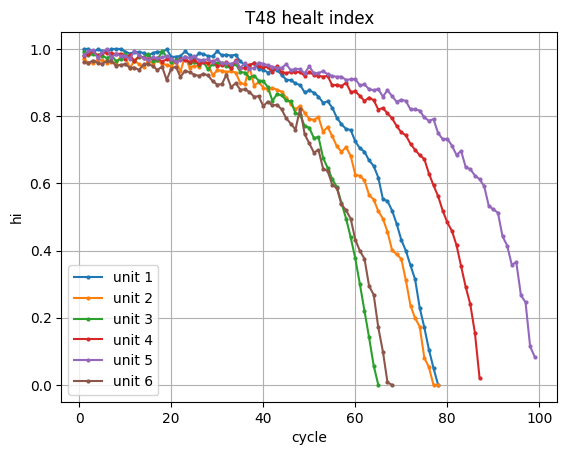

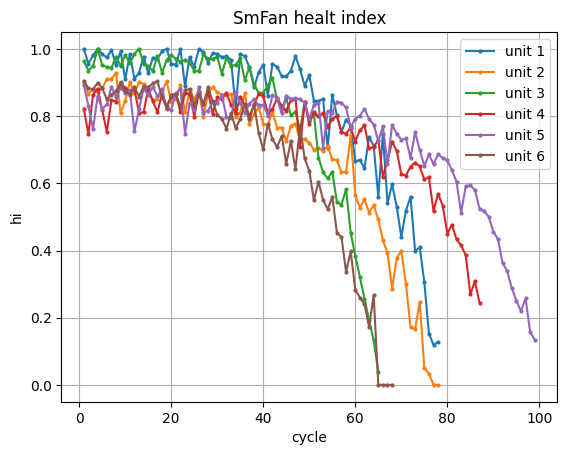

In [17]:
for perf in pipe.get_valid_performances(min_corr=MIN_CORR,min_range=MIN_RANGE):
    fig, ax = plt.subplots()
    ax.set_ylabel("hi") 
    ax.set_title(f"{perf} healt index")
    for unit, df_unit in df_hi.groupby("unit"):
        df_unit.plot(
            x="cycle",
            y=perf,
            ax=ax,
            legend=True,
            label=f"unit {int(unit)}",
            style='-o',
            markersize=2,
            grid=True
        )

## Save estimation data

In [18]:
os.makedirs(ESTIMATION_DIR, exist_ok=True)
df_hi.to_csv(ESTIMATION_DIR/f'data_{data_split}.csv', index=False)